In [ ]:
!pip install snowflake-connector-python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector

In [ ]:
conn = snowflake.connector.connect(
    user = 'Jeevanraj',
    password = 'Jeevanraj12112006',
    account = 'BLHUVTW-IK53044',
    database = 'CHURN_MODELLING',
    schema = 'PUBLIC',
    warehouse = 'COMPUTE_WH'
)

In [ ]:
query = 'select * from Practise'
df = pd.read_sql(query,conn)
conn.close()

/tmp/ipykernel_5570/288124269.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


In [ ]:
df.head()

,ROWNUMBER,CUSTOMERID,SURNAME,CREDITSCORE,GEOGRAPHY,GENDER,AGE,TENURE,BALANCE,NUMOFPRODUCTS,HASCRCARD,ISACTIVEMEMBER,ESTIMATEDSALARY,EXITED
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.tail()

,ROWNUMBER,CUSTOMERID,SURNAME,CREDITSCORE,GEOGRAPHY,GENDER,AGE,TENURE,BALANCE,NUMOFPRODUCTS,HASCRCARD,ISACTIVEMEMBER,ESTIMATEDSALARY,EXITED
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [ ]:
df.isnull().sum()

,0
ROWNUMBER,0
CUSTOMERID,0
SURNAME,0
CREDITSCORE,0
GEOGRAPHY,0
GENDER,0
AGE,0
TENURE,0
BALANCE,0
NUMOFPRODUCTS,0


<Axes: >

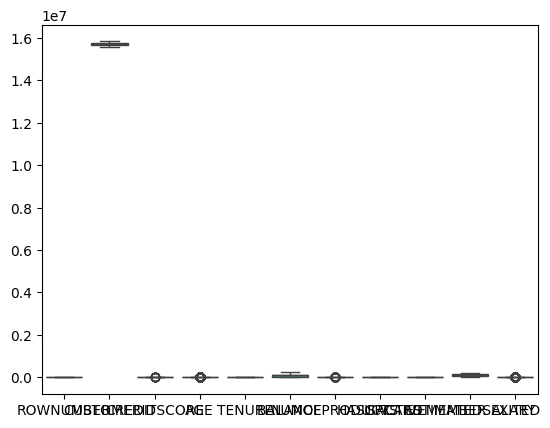

In [ ]:
import seaborn as sns
sns.boxplot(df)

In [ ]:
df.replace([None, "None"], np.nan, inplace=True)

In [ ]:
X=df.drop(columns='EXITED')
y=df['EXITED']

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = X.select_dtypes(include='object').columns

ct = ColumnTransformer([('onehot', OneHotEncoder(handle_unknown='ignore'),cat_cols)],remainder='passthrough')
X_encoded = ct.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.naive_bayes import BernoulliNB

model= BernoulliNB()
model.fit(X_train_scaled, y_train)

y_pred=model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy Score: 0.792
Confusion Matrix:
 [[1552   42]
 [ 374   32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.88      1594
           1       0.43      0.08      0.13       406

    accuracy                           0.79      2000
   macro avg       0.62      0.53      0.51      2000
weighted avg       0.73      0.79      0.73      2000

